# Biblioteki i stałe

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

file_path = "players_22.csv"
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 500
sns.set_palette("tab10")

# Część na 3.0

#### Wczytywanie zbioru danych

In [3]:
df_players = pd.read_csv(file_path)

C:\Users\mikol\AppData\Local\Temp\ipykernel_12892\1673735575.py:1: DtypeWarning: Columns (25,108) have mixed types. Specify dtype option on import or set low_memory=False.
  df_players = pd.read_csv(file_path)


#### Statystyki dla cech numerycznych

In [4]:
df_players_numeric = df_players.select_dtypes(include=['number'])
df_stats = pd.DataFrame([
    df_players_numeric.mean(),
    df_players_numeric.median(),
    df_players_numeric.min(),
    df_players_numeric.max(),
    df_players_numeric.std(),
    df_players_numeric.quantile(0.05),
    df_players_numeric.quantile(0.95),
    df_players_numeric.isna().sum()],
      index=[
    "średnia", 
    "mediana", 
    "min", "max", 
    "odchylenie standardowe", 
    "5-ty percentyl", 
    "95-ty percentyl", 
    "brakujące wartości"])
df_stats = df_stats.T
display(df_stats)

,średnia,mediana,min,max,odchylenie standardowe,5-ty percentyl,95-ty percentyl,brakujące wartości
sofifa_id,2.314681e+05,236543.0,41.0,264640.0,2.703972e+04,184133.9,263046.1,0.0
overall,6.577218e+01,66.0,47.0,93.0,6.880232e+00,54.0,77.0,0.0
potential,7.107937e+01,71.0,49.0,95.0,6.086213e+00,62.0,82.0,0.0
value_eur,2.850452e+06,975000.0,9000.0,194000000.0,7.613700e+06,180000.0,11500000.0,74.0
wage_eur,9.017989e+03,3000.0,500.0,350000.0,1.947018e+04,500.0,37150.0,61.0
age,2.521082e+01,25.0,16.0,54.0,4.748235e+00,18.0,34.0,0.0
height_cm,1.812997e+02,181.0,155.0,206.0,6.863179e+00,170.0,193.0,0.0
weight_kg,7.494303e+01,75.0,49.0,110.0,7.069434e+00,64.0,87.0,0.0
club_team_id,5.058050e+04,1938.0,1.0,115820.0,5.440187e+04,44.0,113301.0,61.0
league_level,1.354364e+00,1.0,1.0,5.0,7.478651e-01,1.0,3.0,61.0


#### Statystyki dla cech nienumerycznych

In [5]:
df_players_nonumeric = df_players.select_dtypes(exclude=['number'])
df_nonumeric_stats = pd.DataFrame([
    df_players_nonumeric.nunique(),
    df_players_nonumeric.isna().sum(),
    df_players_nonumeric.apply(lambda x: x.value_counts(normalize=True).to_dict())],
      index=[
    "liczba unikalnych klas", 
    "brakujące wartości", 
    "proporcja klas"])
df_nonumeric_stats = df_nonumeric_stats.T
display(df_nonumeric_stats)

,liczba unikalnych klas,brakujące wartości,proporcja klas
player_url,19239,0,{'https://sofifa.com/player/264540/emanuel-lal...
short_name,18145,0,"{'J. Rodríguez': 0.0006757107957794064, 'J. He..."
long_name,19219,0,"{'Ladislav Krejčí': 0.0001039555070429856, '刘洋..."
player_positions,674,0,"{'CB': 0.12594209678257706, 'GK': 0.1108165705..."
dob,6312,0,"{'1992-02-29': 0.0064972191901866, '1996-02-29..."
club_name,701,61,"{'Real Betis Balompié': 0.0017207216602356868,..."
league_name,55,61,{'USA Major League Soccer': 0.0402023151527792...
club_position,29,61,"{'SUB': 0.4327354260089686, 'RES': 0.165189279..."
club_loaned_from,334,18137,"{'Sporting CP': 0.012704174228675136, 'Atalant..."
club_joined,1845,1163,"{'2021-07-01': 0.0707014826289002, '2019-07-01..."


# Część na 3.5

#### Boxplot

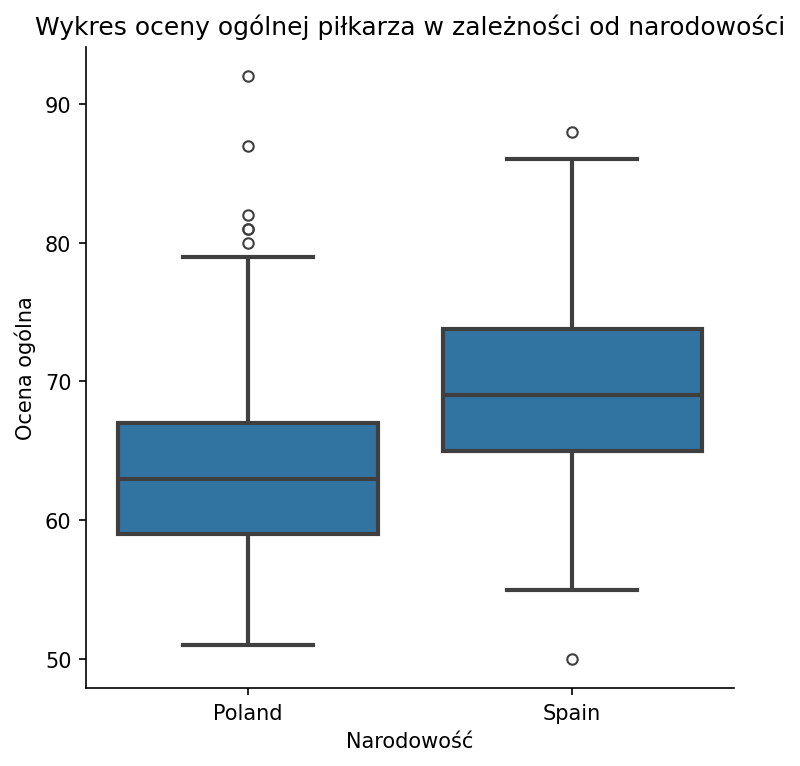

In [6]:
sns.catplot(
    data=df_players, 
    x="nationality_name", 
    y="overall", 
    kind="box", 
    order=["Poland", "Spain"],
    linewidth = 2,
    fliersize = 5)
plt.xlabel("Narodowość")
plt.ylabel("Ocena ogólna")
plt.title("Wykres oceny ogólnej piłkarza w zależności od narodowości")
plt.show()

#### Violinplot

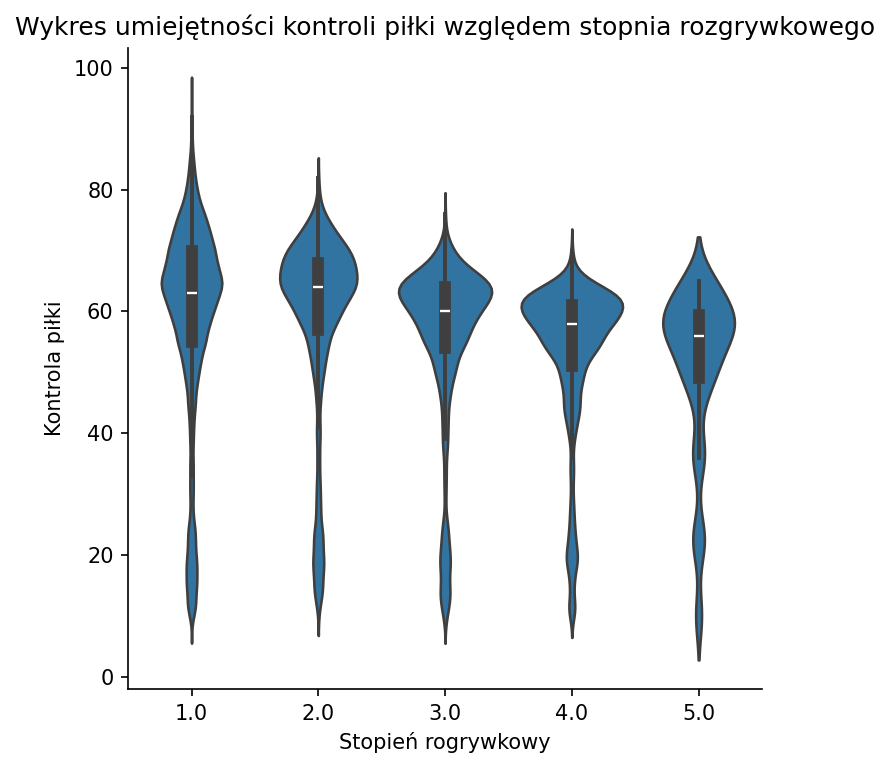

In [7]:
sns.catplot(data=df_players, x="league_level", y="skill_ball_control", kind="violin", bw_adjust=0.5)
plt.xlabel("Stopień rogrywkowy")
plt.ylabel("Kontrola piłki")
plt.title("Wykres umiejętności kontroli piłki względem stopnia rozgrywkowego")
plt.show()

# Część na 4.0

#### Error bars

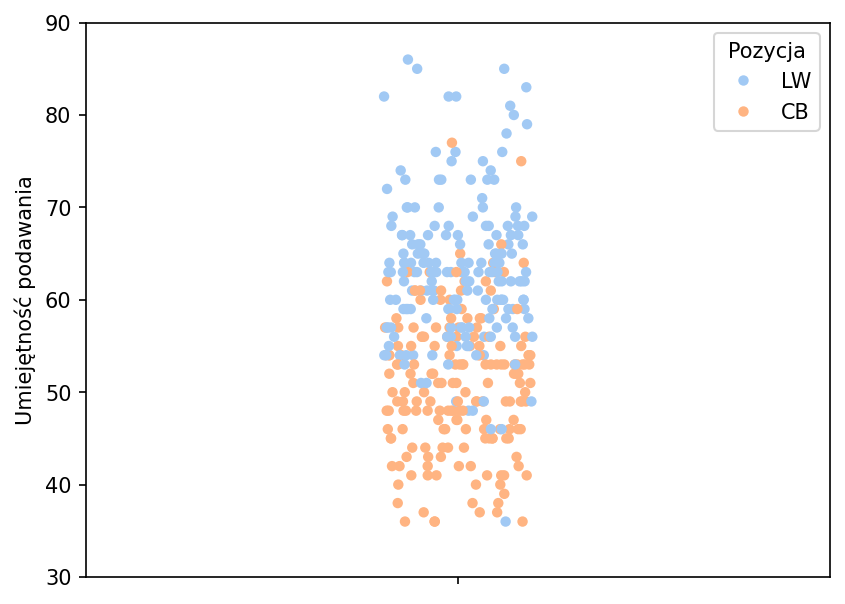

C:\Users\mikol\AppData\Local\Temp\ipykernel_12892\2556508353.py:9: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(data=df_pom, x="club_position", y="passing" , hue="club_position", errorbar=("sd"), join=False,


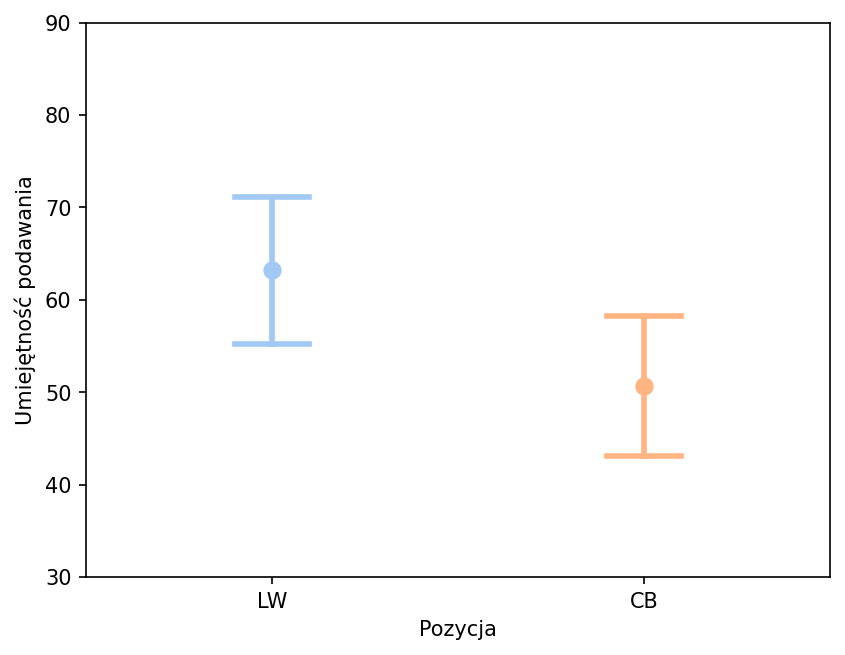

In [8]:
df_pom = df_players[df_players["club_position"].isin(["CB", "LW"])]

sns.stripplot(data=df_pom, y="passing", hue="club_position", palette="pastel")
plt.ylabel("Umiejętność podawania")
plt.legend().set_title("Pozycja")
plt.ylim(30, 90)
plt.show()

sns.pointplot(data=df_pom, x="club_position", y="passing" , hue="club_position", errorbar=("sd"), join=False,
                palette="pastel", capsize=0.2)
plt.ylabel("Umiejętność podawania")
plt.xlabel("Pozycja")
plt.ylim(30, 90)
plt.show()

#### Histogram

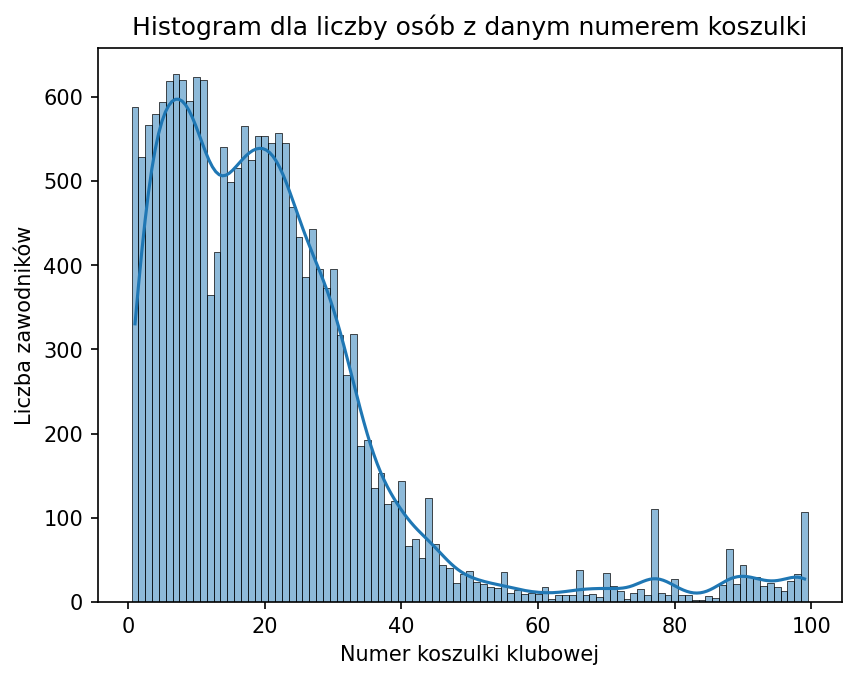

In [9]:
sns.histplot(df_players["club_jersey_number"], bins=100, kde=True, discrete=True)
plt.title("Histogram dla liczby osób z danym numerem koszulki")
plt.xlabel("Numer koszulki klubowej")
plt.ylabel("Liczba zawodników")
plt.show()

#### Histogram warunkowy

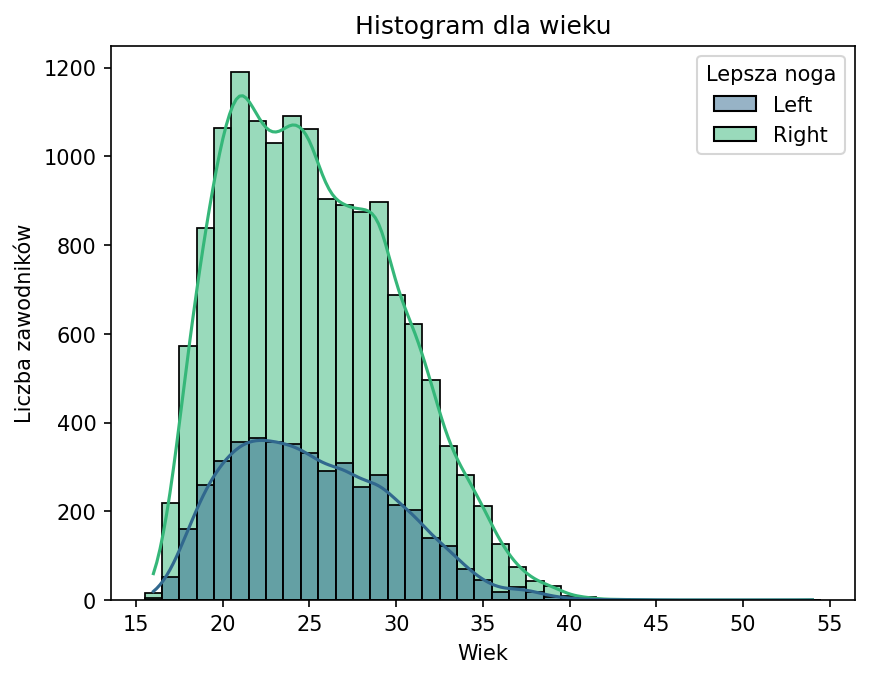

In [10]:
wykres = sns.histplot(df_players, x="age", hue="preferred_foot", bins=100, kde=True, discrete=True, palette="viridis")
plt.title("Histogram dla wieku")
plt.xlabel("Wiek")
plt.ylabel("Liczba zawodników")
legend = plt.gca().get_legend()
legend.set_title('Lepsza noga')
plt.show()

# Część na 4.5

#### Heatmap

Text(0.5, 1.0, 'Heatmap')

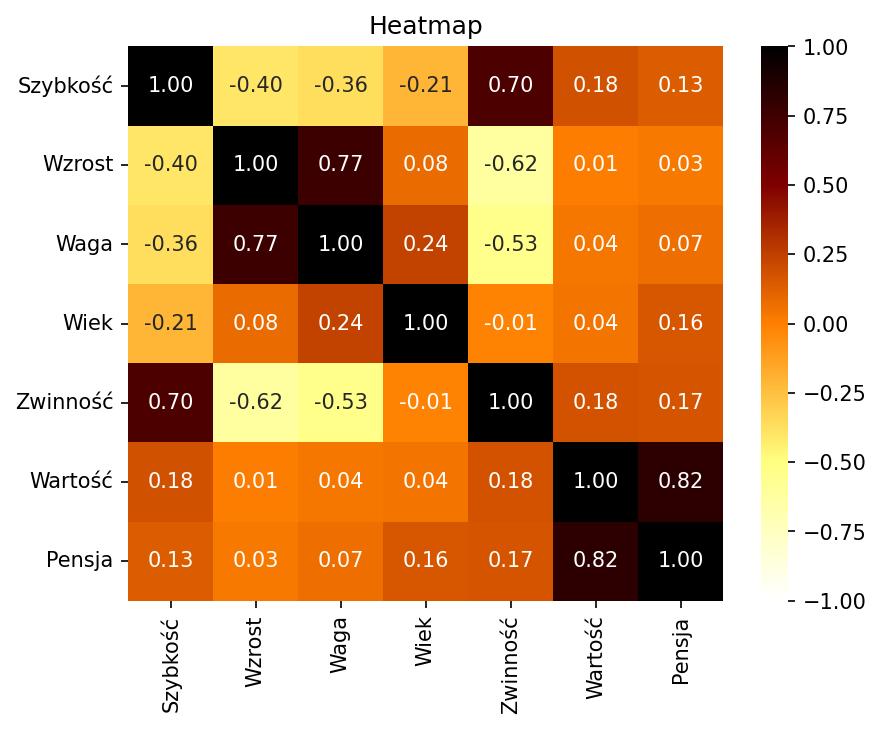

In [11]:
corr_matrix = df_players[["pace", "height_cm", "weight_kg", "age", "movement_agility", "value_eur", "wage_eur"]].corr()
hm = sns.heatmap(data=corr_matrix,
            vmin=-1,
            vmax=1, 
            cmap="afmhot_r", 
            center=0, 
            annot=True, 
            fmt='.2f',  
            linewidths=0, 
            linecolor='black')
hm.set_xticklabels(["Szybkość", "Wzrost", "Waga", "Wiek", "Zwinność", "Wartość", "Pensja"])
hm.set_yticklabels(["Szybkość", "Wzrost", "Waga", "Wiek", "Zwinność", "Wartość", "Pensja"])
plt.title("Heatmap")

# Część na 5.0

Text(0, 0.5, 'Ocena ogólna')

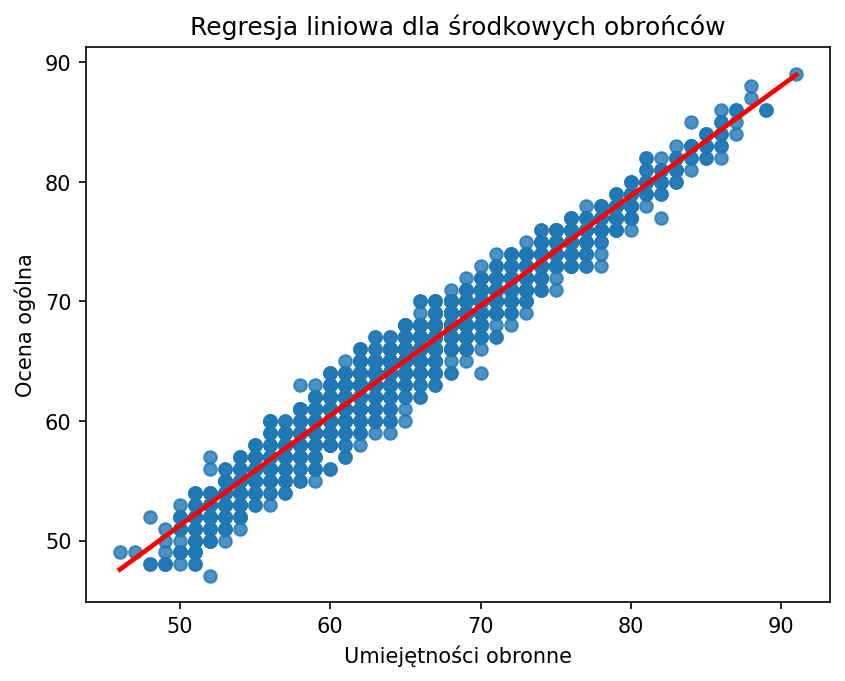

In [12]:
df_strikers = df_players[(df_players["player_positions"] == "CB")]
sns.regplot(data=df_strikers, x="defending", y="overall", line_kws={"color": "red"})

plt.title("Regresja liniowa dla środkowych obrońców")
plt.xlabel("Umiejętności obronne")
plt.ylabel("Ocena ogólna")

# Część na 5.5

C:\Users\mikol\AppData\Local\Temp\ipykernel_12892\23075713.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pca["PCA1"] = X_pca[:, 0]
C:\Users\mikol\AppData\Local\Temp\ipykernel_12892\23075713.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pca["PCA2"] = X_pca[:, 1]


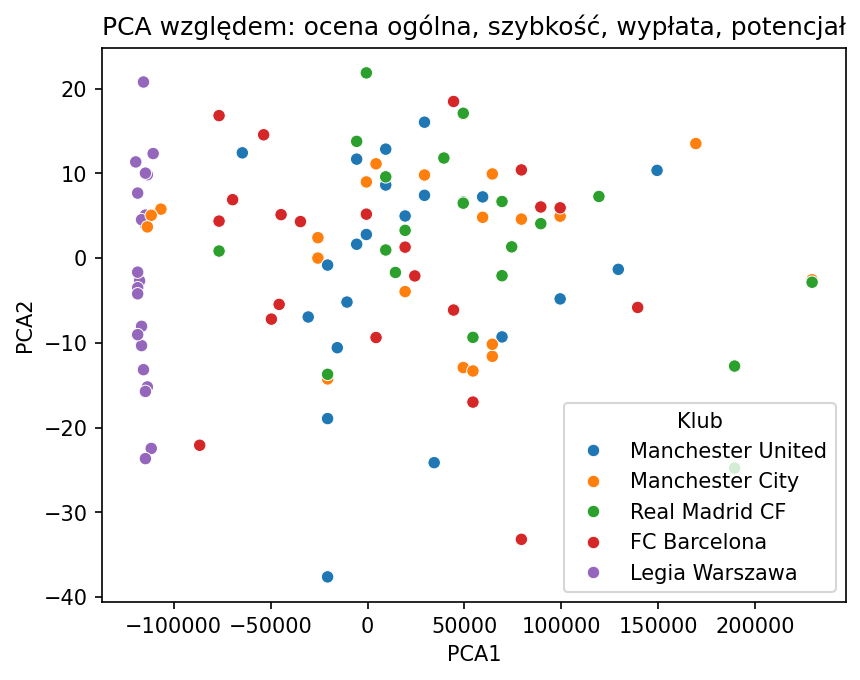

In [13]:
features = ["overall", "pace", "wage_eur", "potential"]
df_pca = df_players[
    (df_players["club_name"].isin(["Real Madrid CF", "FC Barcelona", "Manchester City", "Manchester United", "Legia Warszawa"])) 
    & (df_players["player_positions"] != "GK")
    & (df_players["club_position"] != "RES")]
 
X = df_pca[features]

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

df_pca["PCA1"] = X_pca[:, 0]
df_pca["PCA2"] = X_pca[:, 1]

sns.scatterplot(data=df_pca, x="PCA1", y="PCA2", hue="club_name")
plt.title("PCA względem: ocena ogólna, szybkość, wypłata, potencjał")
plt.legend().set_title("Klub")
plt.show()
